In [ ]:
from zipfile import ZipFile
ZipFile('/content/solar_defects_sample_3class.zip').extractall('/content')

!ls -R /content/solar_defects | head -n 40
print("\n----- solar_data.yaml -----")
print(open('/content/solar_data.yaml').read())

/content/solar_defects:
images
labels

/content/solar_defects/images:
train
val

/content/solar_defects/images/train:
crack_0001.jpg
crack_0002.jpg
crack_0003.jpg
crack_0006.jpg
crack_0010.jpg
crack_0011.jpg
crack_0012.jpg
crack_0014.jpg
crack_0016.jpg
crack_0019.jpg
crack_0028.jpg
crack_0032.jpg
crack_0033.jpg
crack_0036.jpg
dirt_0020.jpg
dirt_0026.jpg
dirt_0027.jpg
dirt_0029.jpg
dirt_0031.jpg
dirt_0035.jpg
dirt_0037.jpg
dirt_0038.jpg
dust_0000.jpg
dust_0004.jpg
dust_0005.jpg
dust_0007.jpg
dust_0008.jpg
dust_0009.jpg
dust_0013.jpg
dust_0015.jpg
dust_0017.jpg

----- solar_data.yaml -----
train: /content/solar_defects/images/train
val: /content/solar_defects/images/val
nc: 3
names: ['dust', 'dirt', 'crack']



In [ ]:
!pip install -q ultralytics opencv-python matplotlib
from ultralytics import YOLO
import torch, glob, cv2, matplotlib.pyplot as plt

print("CUDA available:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: False


In [ ]:
YAML = "/content/solar_data.yaml"   # uses dust, dirt, crack
!yolo task=detect mode=train model=yolov8n.pt data={YAML} \
    epochs=30 imgsz=640 batch=8 \
    lr0=0.005 cos_lr=True \
    hsv_h=0.015 hsv_s=0.8 hsv_v=0.5 \
    degrees=4 translate=0.10 scale=0.60 shear=2 perspective=0.0005 \
    fliplr=0.5 mosaic=1 copy_paste=0.2 erasing=0.2 \
    workers=2

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/solar_data.yaml, degrees=4, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.8, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0005, plots=True, pose=12.0,

In [ ]:
!yolo task=detect mode=val model=runs/detect/train/weights/best.pt data={YAML} imgsz=640

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 649.6±172.4 MB/s, size: 18.1 KB)
val: Scanning /content/solar_defects/labels/val.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 169.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.2s/it 8.3s
                   all         20         20      0.971      0.986      0.995       0.76
                  dust          8          8      0.983          1      0.995      0.726
                  dirt          5          5       0.93          1      0.995      0.838
                 crack          7          7          1      0.959      0.995      0.716
Speed: 18.8ms preprocess, 350.7ms inference, 0.0ms loss, 17.6ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn 

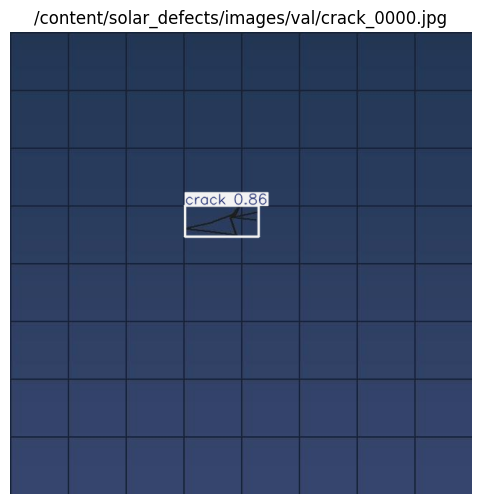

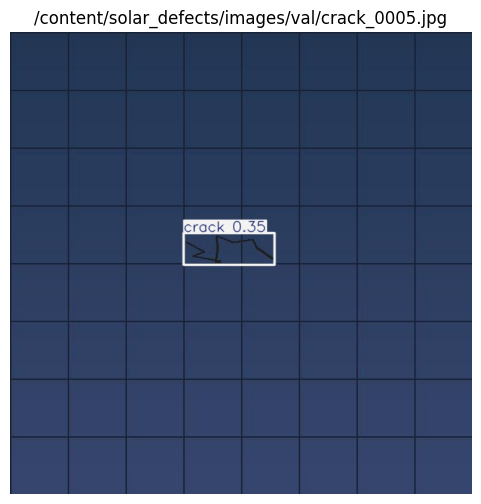

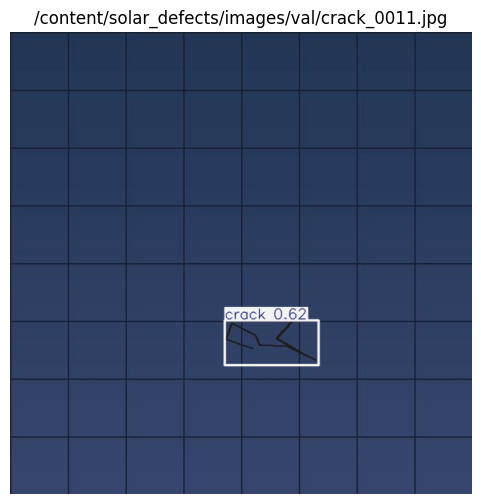

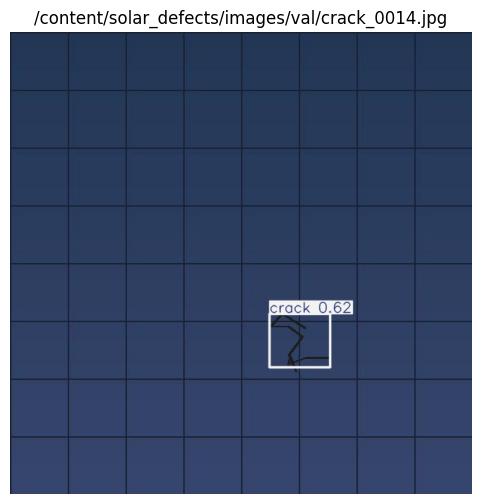

In [ ]:
model = YOLO("runs/detect/train/weights/best.pt")

val_imgs = sorted(glob.glob("/content/solar_defects/images/val/*"))[:4]
for p in val_imgs:
    r = model(p, conf=0.35, imgsz=640, verbose=False)[0]
    im = r.plot()                           # draw boxes on the image
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7,6)); plt.imshow(im); plt.axis('off'); plt.title(p); plt.show()


In [ ]:
!ls /content

download.mp4  sample_data      solar_defects			yolov8n.pt
runs	      solar_data.yaml  solar_defects_sample_3class.zip


In [ ]:
!ls -lh /content


total 6.8M
-rw-r--r-- 1 root root 176K Nov 13 13:35 download.mp4
drwxr-xr-x 3 root root 4.0K Nov 13 13:35 runs
drwxr-xr-x 1 root root 4.0K Nov 11 14:29 sample_data
-rw-r--r-- 1 root root  121 Nov 13 13:35 solar_data.yaml
drwxr-xr-x 4 root root 4.0K Nov 13 13:35 solar_defects
-rw-r--r-- 1 root root 278K Nov 13 13:35 solar_defects_sample_3class.zip
-rw-r--r-- 1 root root 6.3M Nov 13 13:35 yolov8n.pt


In [ ]:
MODEL_PATH = "/content/runs/detect/train/weights/best.pt"

In [ ]:
# --------- CONFIG (edit if needed) ----------
MODEL_PATH = "/content/runs/detect/train/weights/best.pt"   # <-- your trained model
# MODEL_PATH = "/content/yolov8n.pt"                       # (smoke test only)
VIDEO_PATH = "/content/download.mp4"                       # change to your video name shown in Files
OUT_MP4    = "/content/annotated_output.mp4"
IMGSZ = 640
CONF  = 0.35
IOU   = 0.50
# ---------------------------------------------

# install / import
!pip -q install ultralytics imageio imageio-ffmpeg opencv-python
import os, glob, traceback
import imageio.v2 as imageio
import cv2
from ultralytics import YOLO
from IPython.display import Video, display, HTML

# sanity checks
print("MODEL_PATH:", MODEL_PATH)
print("VIDEO_PATH:", VIDEO_PATH)
print("Files in /content:", os.listdir("/content")[:30])

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}. If you haven't trained, use yolov8n.pt for a smoke test.")
if not os.path.exists(VIDEO_PATH):
    raise FileNotFoundError(f"Video not found: {VIDEO_PATH}. Check the exact filename in the left Files pane and update VIDEO_PATH.")

# Open video to fetch fps/size
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    cap.release()
    raise SystemExit(f"Could not open video {VIDEO_PATH} with OpenCV. Try re-uploading or check the file.")
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) or 640
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) or 480
fps = cap.get(cv2.CAP_PROP_FPS) or 15
cap.release()
print(f"Input video: {w}x{h} @ {fps} FPS")

# Create writer (imageio uses ffmpeg under the hood but more robust)
writer = imageio.get_writer(OUT_MP4, fps=fps, codec="libx264", quality=7)

# Load model and stream predictions
model = YOLO(MODEL_PATH)
print("Starting streaming inference (stream=True). This will not accumulate results in RAM.")

try:
    count = 0
    for r in model.predict(source=VIDEO_PATH, imgsz=IMGSZ, conf=CONF, iou=IOU, stream=True, verbose=True):
        # r.plot() returns a BGR image with annotations
        annotated_bgr = r.plot()
        # convert to RGB for writer
        annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
        writer.append_data(annotated_rgb)
        count += 1
    writer.close()
    print(f"Saved annotated video to: {OUT_MP4}  (frames written: {count})")
    display(Video(OUT_MP4, embed=True))
except Exception as e:
    # Clean up writer if an error happened
    try:
        writer.close()
    except:
        pass
    print("An error occurred during streaming inference or writing. Traceback:")
    traceback.print_exc()
    # Attempt to list any detect output folders for diagnostics
    preds = sorted(glob.glob("/content/runs/detect/predict*"))
    if preds:
        print("Detector saved files to:", preds[-1], "contents:", os.listdir(preds[-1])[:30])
    raise

# Helpful note if you saw "(no detections)" messages above:
if os.path.basename(MODEL_PATH) == "yolov8n.pt":
    print("\n⚠️ NOTE: You're using the COCO pretrained model (yolov8n.pt). It doesn't include classes like 'dust'/'dirt'/'crack'.")
    print("Train a custom model and then set MODEL_PATH to /content/runs/detect/train/weights/best.pt and re-run.")
else:
    print("\nIf you still see no detections, try lowering CONF (e.g. 0.2) or increasing IMGSZ for tiny objects (e.g. 960).")


MODEL_PATH: /content/runs/detect/train/weights/best.pt
VIDEO_PATH: /content/download.mp4
Files in /content: ['.config', 'solar_data.yaml', 'yolov8n.pt', 'solar_defects_sample_3class.zip', 'solar_defects', 'runs', 'download.mp4', 'sample_data']
Input video: 640x480 @ 15.0 FPS
Starting streaming inference (stream=True). This will not accumulate results in RAM.

video 1/1 (frame 1/180) /content/download.mp4: 480x640 (no detections), 173.8ms
video 1/1 (frame 2/180) /content/download.mp4: 480x640 (no detections), 187.4ms
video 1/1 (frame 3/180) /content/download.mp4: 480x640 (no detections), 161.2ms
video 1/1 (frame 4/180) /content/download.mp4: 480x640 (no detections), 171.9ms
video 1/1 (frame 5/180) /content/download.mp4: 480x640 (no detections), 173.3ms
video 1/1 (frame 6/180) /content/download.mp4: 480x640 (no detections), 170.9ms
video 1/1 (frame 7/180) /content/download.mp4: 480x640 (no detections), 175.4ms
video 1/1 (frame 8/180) /content/download.mp4: 480x640 (no detections), 166.6m


If you still see no detections, try lowering CONF (e.g. 0.2) or increasing IMGSZ for tiny objects (e.g. 960).
